# Kaggle Library Install

In [1]:
!pip install -q kaggle

In [2]:
from google.colab import files

In [3]:
!kaggle datasets download -d ozguraslank/brain-stroke-ct-dataset

Dataset URL: https://www.kaggle.com/datasets/ozguraslank/brain-stroke-ct-dataset
License(s): other
100% 1.41G/1.41G [00:20<00:00, 73.9MB/s]



In [5]:
!unzip -q /content/brain-stroke-ct-dataset.zip

# Importing Libraries

In [6]:

!pip -q install kagglehub seaborn scikit-learn pillow statsmodels

import os
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    roc_auc_score,
    precision_recall_fscore_support
)

import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, BatchNormalization, Activation
from tensorflow.keras.layers import MaxPooling2D, GlobalAveragePooling2D
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)
from tensorflow.keras.preprocessing.image import (
    ImageDataGenerator,
    load_img,
    img_to_array
)
from tensorflow.keras.applications import (
    MobileNetV2,
    EfficientNetB0,
    ResNet50,
    VGG16,
    DenseNet121
)
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess

print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))


TensorFlow: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Configuration



In [7]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

IMG_SIZE = 224
BATCH_SIZE = 16


EPOCHS = 30


FINE_TUNE_EPOCHS = 15

NUM_CLASSES = 3

CLASS_NAMES = [
    "Normal",
    "Ischemia",
    "Bleeding"
]

BACKBONE_NAME = "EfficientNetB0"



OUTPUT_DIR = "/content/brain_stroke_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)


DATASET_DIR = "/content/Brain_Stroke_CT_Dataset"

print("Backbone:", BACKBONE_NAME)
print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Output:", OUTPUT_DIR)


Backbone: EfficientNetB0
Image size: 224
Batch size: 16
Output: /content/brain_stroke_outputs


In [8]:
DATASET_ROOT = "/content/Brain_Stroke_CT_Dataset"

print("Dataset root:", DATASET_ROOT)


Dataset root: /content/Brain_Stroke_CT_Dataset


In [9]:
def find_folder(root, target):
    matches = []

    for current_root, dirs, files in os.walk(root):
        for d in dirs:
            if d.lower() == target.lower():
                matches.append(os.path.join(current_root, d))

    return matches[0] if matches else None

class_directories = {}

for class_name in CLASS_NAMES:
    folder = find_folder(DATASET_ROOT, class_name)
    class_directories[class_name] = folder
    print(f"{class_name}: {folder}")

missing = [c for c, p in class_directories.items() if p is None]

if missing:
    raise FileNotFoundError(
        "Could not find class folders: " + ", ".join(missing)
    )


Normal: /content/Brain_Stroke_CT_Dataset/Normal
Ischemia: /content/Brain_Stroke_CT_Dataset/Ischemia
Bleeding: /content/Brain_Stroke_CT_Dataset/Bleeding


## Data Collection and Class Distribution


In [10]:
IMAGE_EXTENSIONS = (
    ".jpg", ".jpeg", ".png",
    ".bmp", ".tif", ".tiff"
)

records = []

for label, class_name in enumerate(CLASS_NAMES):

    folder = class_directories[class_name]

    for root, dirs, files in os.walk(folder):

        for filename in files:

            if filename.lower().endswith(IMAGE_EXTENSIONS):

                records.append({
                    "filepath": os.path.join(root, filename),
                    "label": label,
                    "class": class_name
                })

df = pd.DataFrame(records)

print("Total images:", len(df))
display(df.head())

print("\nClass distribution:")
display(df["class"].value_counts().rename_axis("class").reset_index(name="count"))


Total images: 8873


,filepath,label,class
0,/content/Brain_Stroke_CT_Dataset/Normal/PNG/16...,0,Normal
1,/content/Brain_Stroke_CT_Dataset/Normal/PNG/10...,0,Normal
2,/content/Brain_Stroke_CT_Dataset/Normal/PNG/14...,0,Normal
3,/content/Brain_Stroke_CT_Dataset/Normal/PNG/16...,0,Normal
4,/content/Brain_Stroke_CT_Dataset/Normal/PNG/16...,0,Normal



Class distribution:


,class,count
0,Normal,4427
1,Ischemia,2260
2,Bleeding,2186


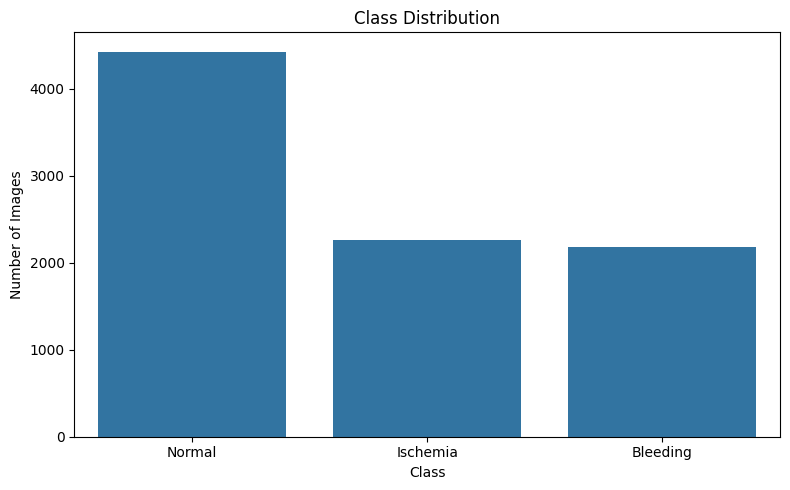

In [11]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="class", order=CLASS_NAMES)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/class_distribution.png", dpi=300)
plt.show()


## Sample images


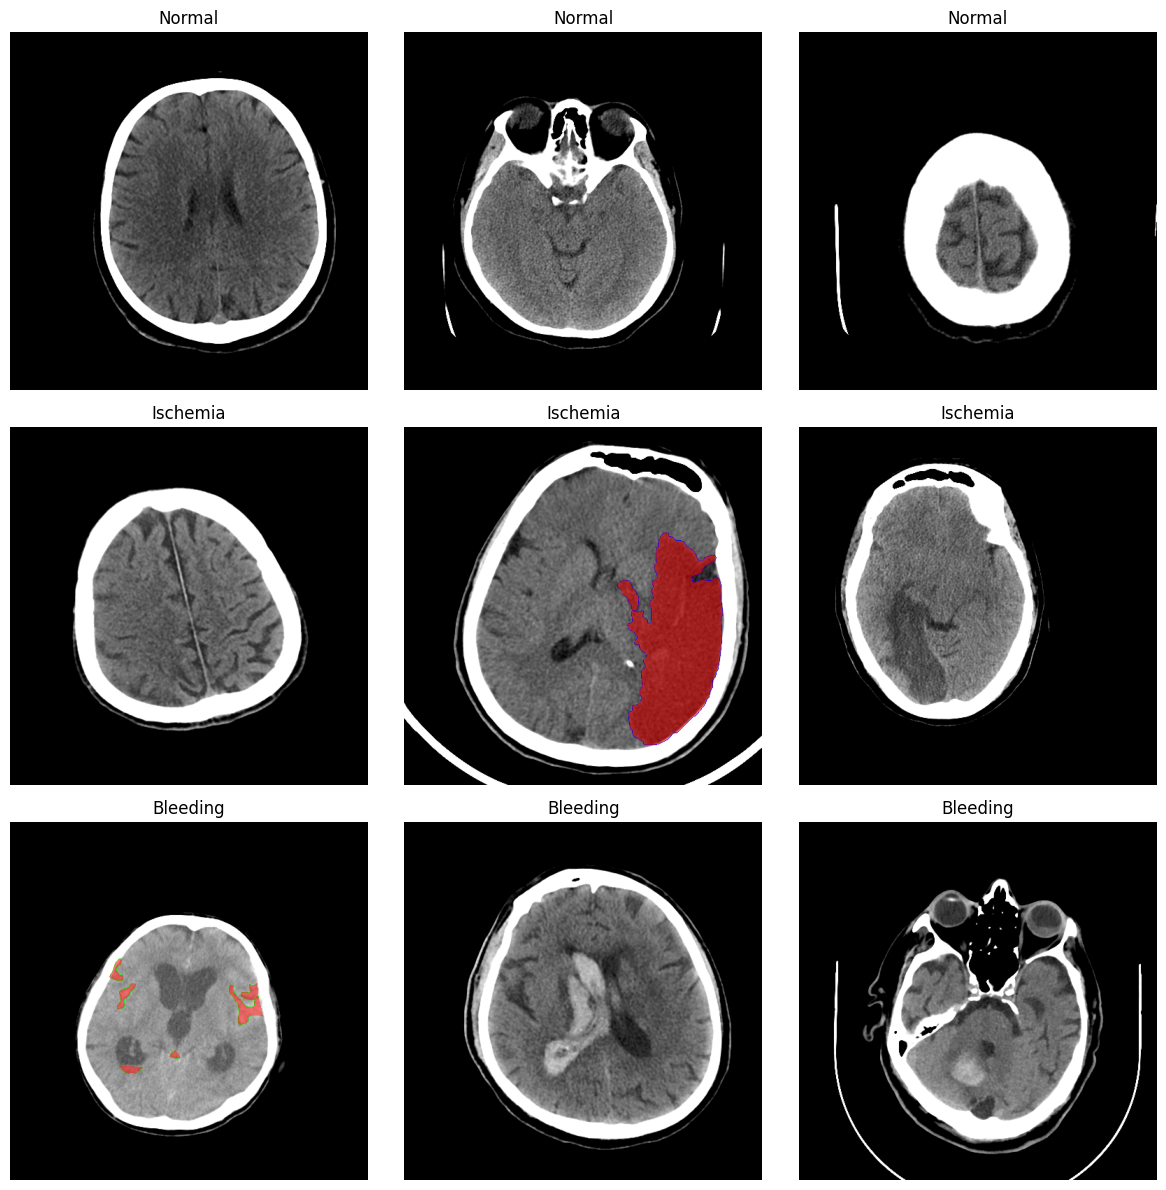

In [12]:
fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for row, class_name in enumerate(CLASS_NAMES):

    class_df = df[df["class"] == class_name]

    samples = class_df.sample(
        min(3, len(class_df)),
        random_state=SEED
    )

    for col, (_, sample) in enumerate(samples.iterrows()):

        image = Image.open(sample["filepath"]).convert("RGB")

        axes[row, col].imshow(image)
        axes[row, col].set_title(class_name)
        axes[row, col].axis("off")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/sample_images.png", dpi=300)
plt.show()


## Feature Engineering for EDA, Scaling, Feature Selection and Clustering




In [13]:
def extract_image_features(path):

    image = Image.open(path).convert("L")
    image = image.resize((128, 128))

    arr = np.asarray(image, dtype=np.float32) / 255.0
    pixels = arr.flatten()

    return {
        "mean_intensity": np.mean(pixels),
        "std_intensity": np.std(pixels),
        "min_intensity": np.min(pixels),
        "max_intensity": np.max(pixels),
        "median_intensity": np.median(pixels),
        "q25_intensity": np.percentile(pixels, 25),
        "q75_intensity": np.percentile(pixels, 75),
        "dark_pixel_ratio": np.mean(pixels < 0.20),
        "bright_pixel_ratio": np.mean(pixels > 0.80),
        "edge_strength": np.mean(np.abs(np.diff(arr, axis=0))),
        "horizontal_variance": np.var(np.mean(arr, axis=0)),
        "vertical_variance": np.var(np.mean(arr, axis=1))
    }

feature_records = []

for _, row in df.iterrows():

    features = extract_image_features(row["filepath"])
    features["class"] = row["class"]
    features["label"] = row["label"]

    feature_records.append(features)

features_df = pd.DataFrame(feature_records)

print("Engineered feature shape:", features_df.shape)
display(features_df.head())


Engineered feature shape: (8873, 14)


,mean_intensity,std_intensity,min_intensity,max_intensity,median_intensity,q25_intensity,q75_intensity,dark_pixel_ratio,bright_pixel_ratio,edge_strength,horizontal_variance,vertical_variance,class,label
0,0.125717,0.304482,0.0,1.0,0.0,0.0,0.000000,0.838074,0.096008,0.013522,0.019696,0.019469,Normal,0
1,0.180801,0.304582,0.0,1.0,0.0,0.0,0.345098,0.717041,0.077454,0.046982,0.028923,0.015580,Normal,0
2,0.215258,0.297534,0.0,1.0,0.0,0.0,0.419608,0.614136,0.070312,0.043703,0.021369,0.020078,Normal,0
3,0.241978,0.379625,0.0,1.0,0.0,0.0,0.549020,0.690002,0.162109,0.041543,0.040034,0.030651,Normal,0
4,0.175190,0.299262,0.0,1.0,0.0,0.0,0.345098,0.707764,0.078003,0.035843,0.022634,0.016365,Normal,0


# HISTOGRAMS


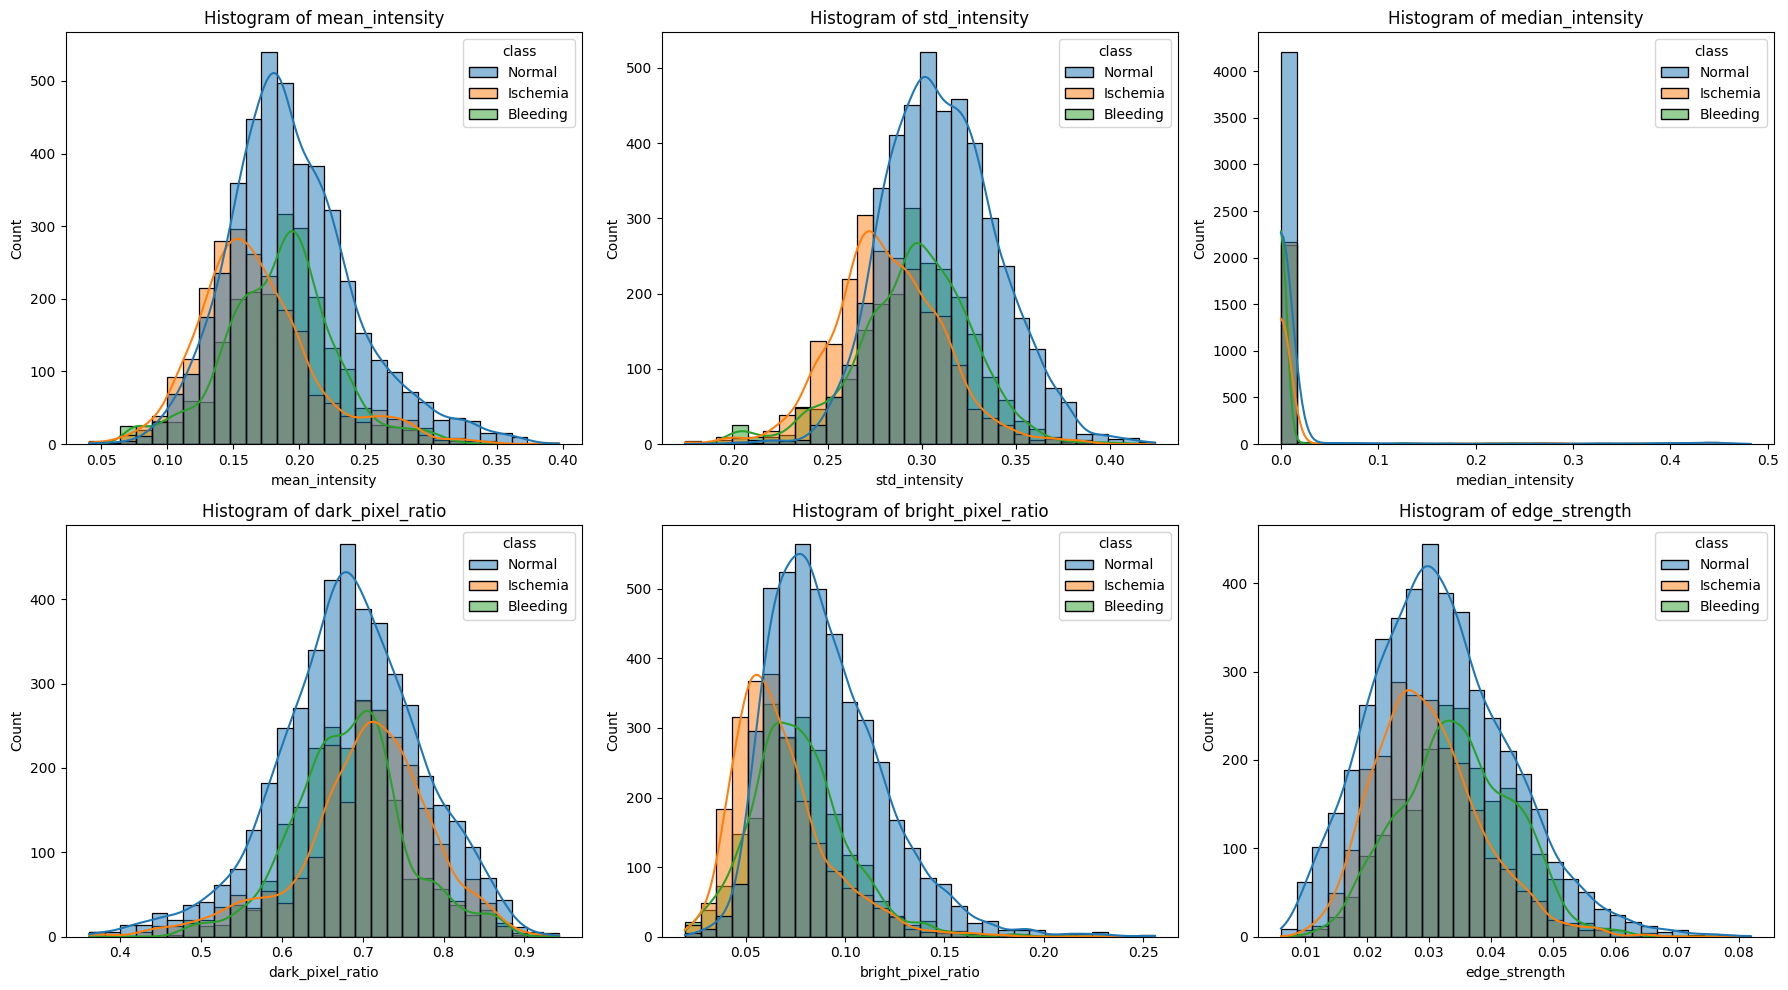

In [21]:
numeric_features = [
    "mean_intensity",
    "std_intensity",
    "median_intensity",
    "dark_pixel_ratio",
    "bright_pixel_ratio",
    "edge_strength"
]

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

for i, feature in enumerate(numeric_features):
    sns.histplot(
        data=features_df,
        x=feature,
        hue="class",
        kde=True,
        bins=30,
        ax=axes[i]
    )
    axes[i].set_title(f"Histogram of {feature}")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/all_histograms.png", dpi=300)
plt.show()

# Box Plots

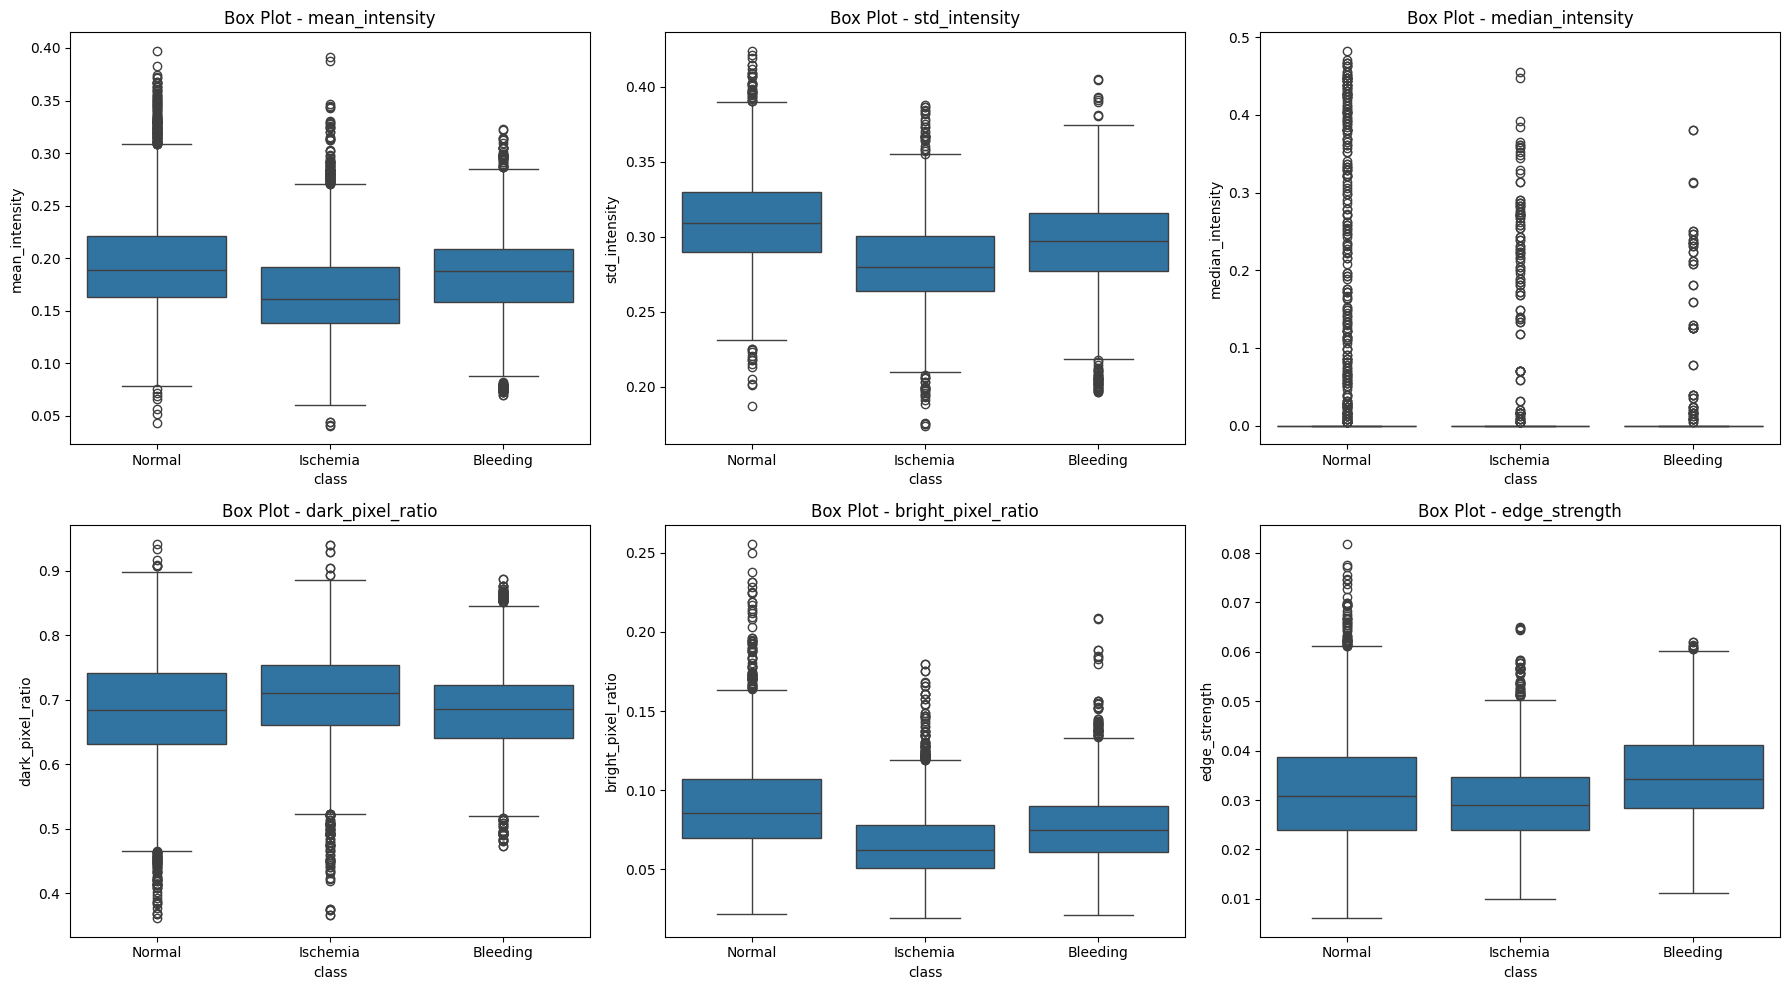

In [22]:
numeric_features = [
    "mean_intensity",
    "std_intensity",
    "median_intensity",
    "dark_pixel_ratio",
    "bright_pixel_ratio",
    "edge_strength"
]

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

for i, feature in enumerate(numeric_features):
    sns.boxplot(
        data=features_df,
        x="class",
        y=feature,
        order=CLASS_NAMES,
        ax=axes[i]
    )
    axes[i].set_title(f"Box Plot - {feature}")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/all_boxplots.png", dpi=300)
plt.show()

# Scatter Plot

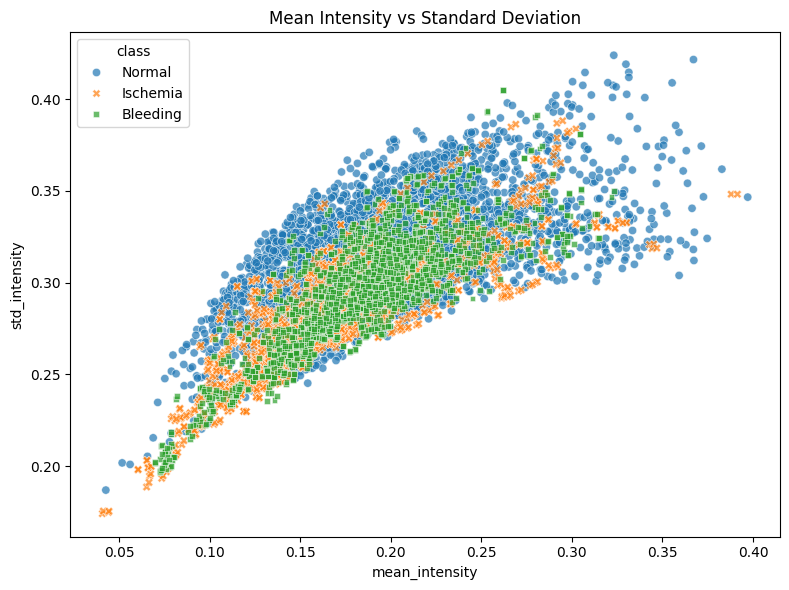

In [18]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=features_df,
    x="mean_intensity",
    y="std_intensity",
    hue="class",
    style="class",
    alpha=0.7
)

plt.title("Mean Intensity vs Standard Deviation")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/scatter_plot.png", dpi=300)
plt.show()


# Regression Plot

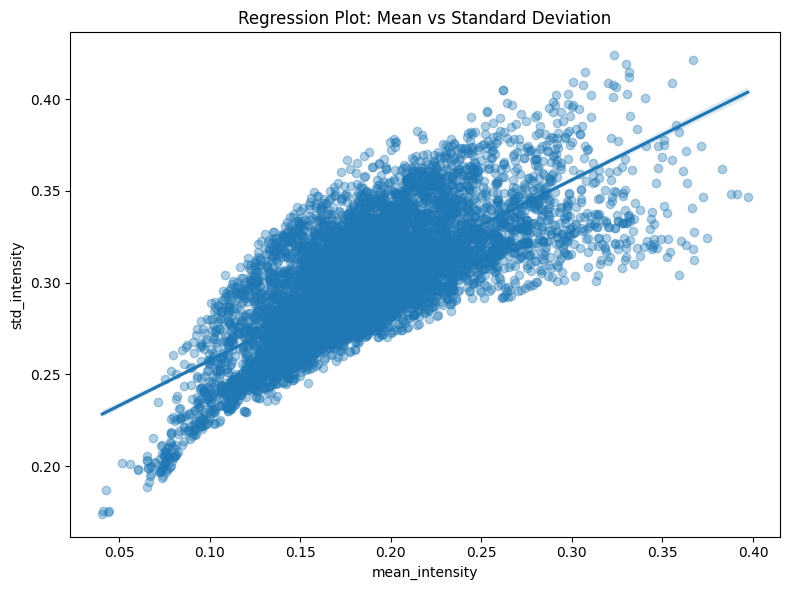

In [19]:
plt.figure(figsize=(8, 6))

sns.regplot(
    data=features_df,
    x="mean_intensity",
    y="std_intensity",
    scatter_kws={"alpha": 0.35}
)

plt.title("Regression Plot: Mean vs Standard Deviation")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/regression_plot.png", dpi=300)
plt.show()

# Heatmap

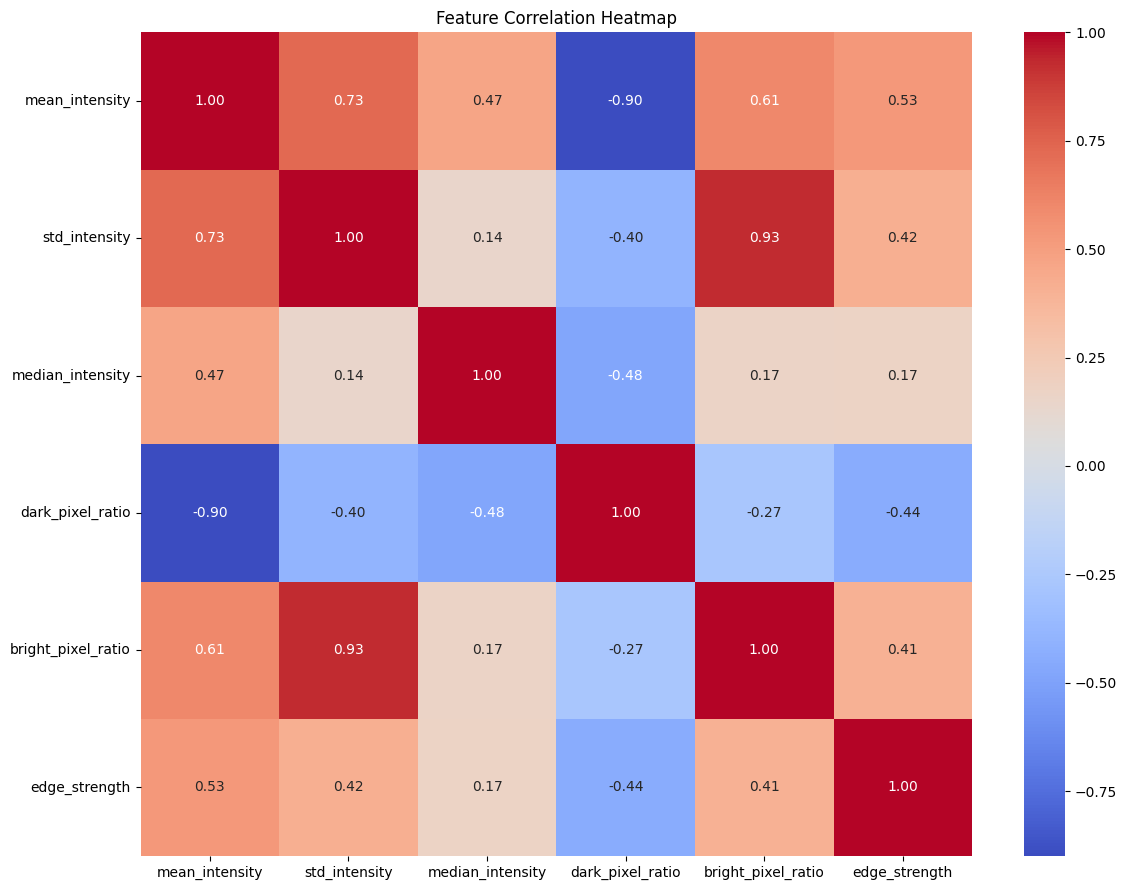

In [23]:
plt.figure(figsize=(12, 9))

correlation_matrix = features_df[numeric_features].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/feature_correlation_heatmap.png", dpi=300)
plt.show()

# Pairplot

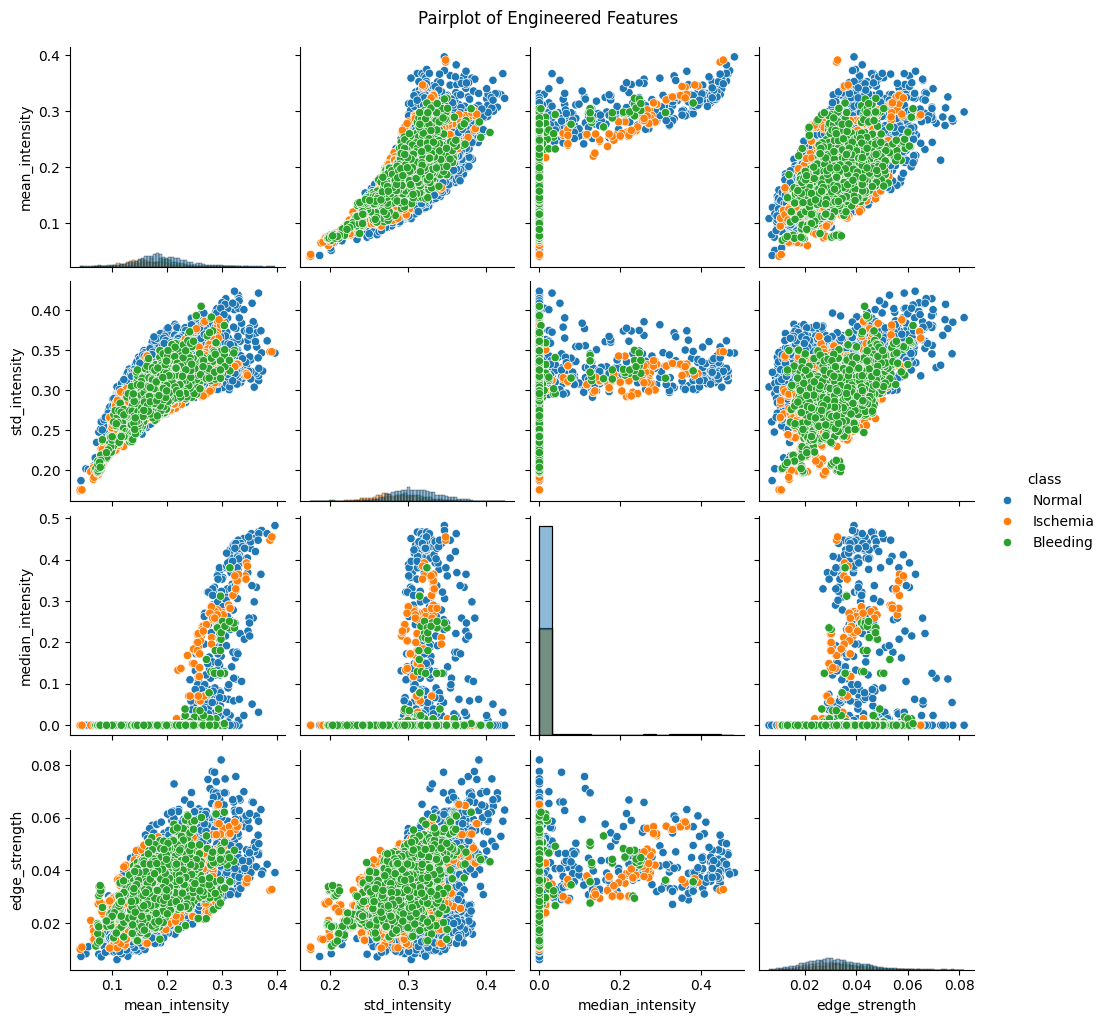

In [24]:
pairplot_features = [
    "mean_intensity",
    "std_intensity",
    "median_intensity",
    "edge_strength"
]

g = sns.pairplot(
    features_df[pairplot_features + ["class"]],
    hue="class",
    diag_kind="hist"
)

g.fig.suptitle(
    "Pairplot of Engineered Features",
    y=1.02
)

g.savefig(f"{OUTPUT_DIR}/pairplot.png", dpi=300)
plt.show()

## Scaling and Feature Selection


Scaled feature matrix: (8873, 6)
Selected features:
- mean_intensity
- std_intensity
- dark_pixel_ratio
- bright_pixel_ratio
- edge_strength


,feature,score,selected
1,std_intensity,733.629145,True
4,bright_pixel_ratio,627.703920,True
0,mean_intensity,250.959552,True
5,edge_strength,123.392754,True
3,dark_pixel_ratio,43.782525,True
2,median_intensity,20.138219,False


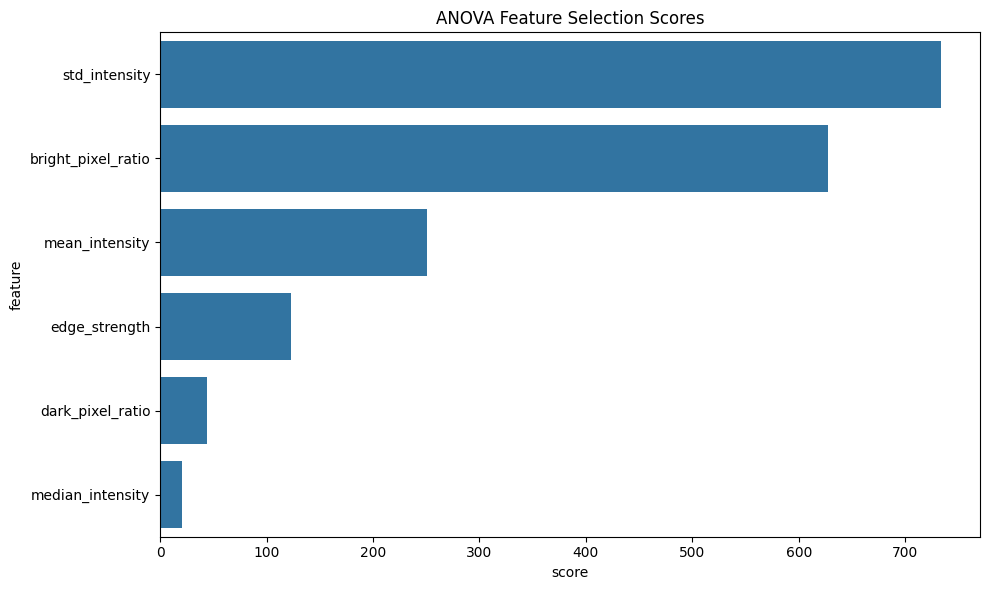

In [25]:
X_features = features_df[numeric_features]
y_features = features_df["label"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)

print("Scaled feature matrix:", X_scaled.shape)

k = min(5, X_scaled.shape[1])

selector = SelectKBest(
    score_func=f_classif,
    k=k
)

X_selected = selector.fit_transform(
    X_scaled,
    y_features
)

selected_feature_names = [
    feature
    for feature, selected
    in zip(numeric_features, selector.get_support())
    if selected
]

feature_scores = pd.DataFrame({
    "feature": numeric_features,
    "score": selector.scores_,
    "selected": selector.get_support()
}).sort_values("score", ascending=False)

print("Selected features:")
for feature in selected_feature_names:
    print("-", feature)

display(feature_scores)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_scores,
    x="score",
    y="feature"
)

plt.title("ANOVA Feature Selection Scores")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/feature_selection.png", dpi=300)
plt.show()


## Train/Validation/Test split

In [26]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=SEED,
    stratify=df["label"]
)

validation_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df["label"]
)

train_df = train_df.reset_index(drop=True)
validation_df = validation_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Training:", len(train_df))
print("Validation:", len(validation_df))
print("Testing:", len(test_df))

print("\nTraining distribution:")
display(train_df["class"].value_counts())

print("\nValidation distribution:")
display(validation_df["class"].value_counts())

print("\nTesting distribution:")
display(test_df["class"].value_counts())


Training: 6211
Validation: 1331
Testing: 1331

Training distribution:


,count
class,
Normal,3099
Ischemia,1582
Bleeding,1530



Validation distribution:


,count
class,
Normal,664
Ischemia,339
Bleeding,328



Testing distribution:


,count
class,
Normal,664
Ischemia,339
Bleeding,328


## Data Augmentation and Generators

In [27]:
train_datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    shear_range=0.05,
    horizontal_flip=True,
    fill_mode="nearest"
)

validation_datagen = ImageDataGenerator()
test_datagen = ImageDataGenerator()


train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="filepath",
    y_col="class",
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

validation_generator = validation_datagen.flow_from_dataframe(
    dataframe=validation_df,
    x_col="filepath",
    y_col="class",
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="filepath",
    y_col="class",
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Generator class indices:")
print(train_generator.class_indices)


Found 6211 validated image filenames belonging to 3 classes.
Found 1331 validated image filenames belonging to 3 classes.
Found 1331 validated image filenames belonging to 3 classes.
Generator class indices:
{'Bleeding': 0, 'Ischemia': 1, 'Normal': 2}


## Transfer-learning backbone

In [28]:
def get_backbone(name):

    name = name.lower()

    input_shape = (IMG_SIZE, IMG_SIZE, 3)

    if name == "mobilenetv2":
        backbone = MobileNetV2(
            include_top=False,
            weights="imagenet",
            input_shape=input_shape
        )
        preprocess = mobilenet_preprocess

    elif name == "efficientnetb0":
        backbone = EfficientNetB0(
            include_top=False,
            weights="imagenet",
            input_shape=input_shape
        )
        preprocess = efficientnet_preprocess

    elif name == "resnet50":
        backbone = ResNet50(
            include_top=False,
            weights="imagenet",
            input_shape=input_shape
        )
        preprocess = resnet_preprocess

    elif name == "vgg16":
        backbone = VGG16(
            include_top=False,
            weights="imagenet",
            input_shape=input_shape
        )
        preprocess = vgg_preprocess

    elif name == "densenet121":
        backbone = DenseNet121(
            include_top=False,
            weights="imagenet",
            input_shape=input_shape
        )
        preprocess = densenet_preprocess

    else:
        raise ValueError(
            "Choose one of: MobileNetV2, EfficientNetB0, "
            "ResNet50, VGG16, DenseNet121"
        )

    return backbone, preprocess


backbone, preprocess_function = get_backbone(
    BACKBONE_NAME
)

print("Loaded:", BACKBONE_NAME)
print("Number of backbone layers:", len(backbone.layers))


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Loaded: EfficientNetB0
Number of backbone layers: 238


## CNN architecture

In [29]:
backbone.trainable = False

inputs = layers.Input(
    shape=(IMG_SIZE, IMG_SIZE, 3),
    name="input_image"
)

x = layers.Lambda(
    preprocess_function,
    name="preprocessing"
)(inputs)

x = backbone(
    x,
    training=False
)

x = layers.GlobalAveragePooling2D(
    name="global_average_pooling"
)(x)

x = layers.Dense(
    256,
    activation="relu",
    name="dense_feature_layer"
)(x)

x = layers.BatchNormalization(
    name="batch_normalization"
)(x)

x = layers.Dropout(
    0.40
)(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    name="classification_output"
)(x)

model = Model(
    inputs=inputs,
    outputs=outputs
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ preprocessing (Lambda)          │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_feature_layer (Dense)     │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification_output (Dense)   │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,379,302 (16.71 MB)

 Trainable params: 329,219 (1.26 MB)

 Non-trainable params: 4,050,083 (15.45 MB)

## Early stopping, checkpointing and training


In [30]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=6,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    filepath=os.path.join(
        OUTPUT_DIR,
        "best_brain_stroke_model.keras"
    ),
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=3,
    min_lr=1e-7,
    verbose=1
)


history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS,
    callbacks=[
        early_stopping,
        checkpoint,
        reduce_lr
    ]
)


Epoch 1/30
389/389 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step - accuracy: 0.6768 - loss: 0.8257
Epoch 1: val_accuracy improved from None to 0.80691, saving model to /content/brain_stroke_outputs/best_brain_stroke_model.keras

Epoch 1: finished saving model to /content/brain_stroke_outputs/best_brain_stroke_model.keras
389/389 ━━━━━━━━━━━━━━━━━━━━ 159s 335ms/step - accuracy: 0.7271 - loss: 0.6937 - val_accuracy: 0.8069 - val_loss: 0.5552 - learning_rate: 0.0010
Epoch 2/30
389/389 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step - accuracy: 0.7740 - loss: 0.5636
Epoch 2: val_accuracy improved from 0.80691 to 0.83621, saving model to /content/brain_stroke_outputs/best_brain_stroke_model.keras

Epoch 2: finished saving model to /content/brain_stroke_outputs/best_brain_stroke_model.keras
389/389 ━━━━━━━━━━━━━━━━━━━━ 97s 249ms/step - accuracy: 0.7860 - loss: 0.5412 - val_accuracy: 0.8362 - val_loss: 0.4274 - learning_rate: 0.0010
Epoch 3/30
389/389 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step - accuracy: 0.8024 - loss: 0.5

## Fine-tuning

In [31]:
backbone.trainable = True

fine_tune_from = int(
    len(backbone.layers) * 0.70
)

for layer in backbone.layers[:fine_tune_from]:
    layer.trainable = False

for layer in backbone.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

fine_tune_history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=[
        early_stopping,
        checkpoint,
        reduce_lr
    ]
)


Epoch 1/15
389/389 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step - accuracy: 0.8803 - loss: 0.3201
Epoch 1: val_accuracy did not improve from 0.89406
389/389 ━━━━━━━━━━━━━━━━━━━━ 161s 329ms/step - accuracy: 0.8828 - loss: 0.3154 - val_accuracy: 0.8881 - val_loss: 0.2880 - learning_rate: 1.0000e-05
Epoch 2/15
389/389 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step - accuracy: 0.8904 - loss: 0.2997
Epoch 2: val_accuracy did not improve from 0.89406
389/389 ━━━━━━━━━━━━━━━━━━━━ 100s 257ms/step - accuracy: 0.8910 - loss: 0.2976 - val_accuracy: 0.8888 - val_loss: 0.2844 - learning_rate: 1.0000e-05
Epoch 3/15
389/389 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step - accuracy: 0.8947 - loss: 0.2751
Epoch 3: val_accuracy did not improve from 0.89406
389/389 ━━━━━━━━━━━━━━━━━━━━ 102s 262ms/step - accuracy: 0.8962 - loss: 0.2805 - val_accuracy: 0.8933 - val_loss: 0.2853 - learning_rate: 1.0000e-05
Epoch 4/15
389/389 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - accuracy: 0.8972 - loss: 0.2785
Epoch 4: val_accuracy improved from 0.89406 to 0

# Accuracy Curve

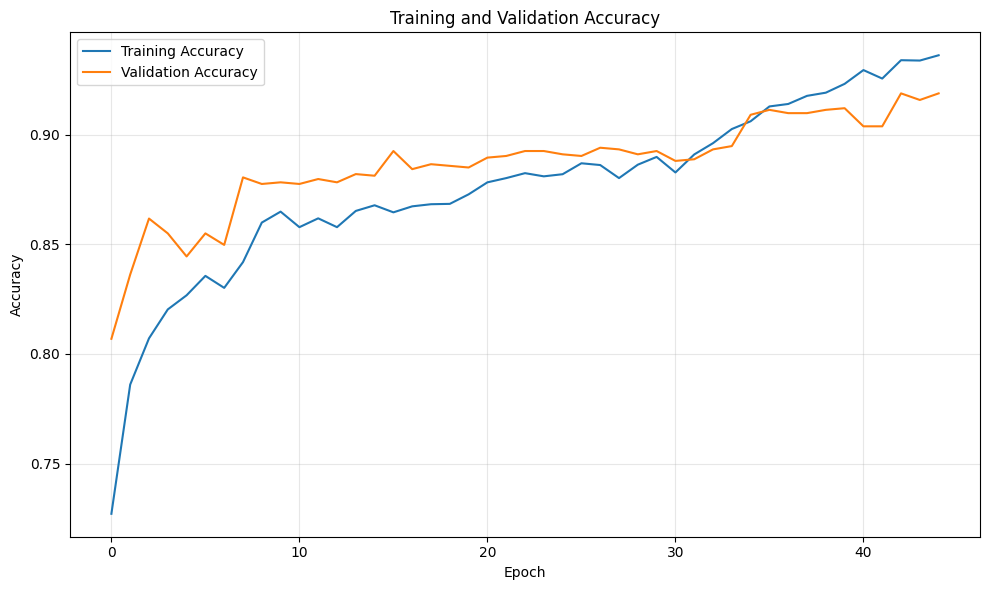

In [34]:
acc = history.history["accuracy"] + fine_tune_history.history["accuracy"]
val_acc = history.history["val_accuracy"] + fine_tune_history.history["val_accuracy"]


plt.figure(figsize=(10, 6))

plt.plot(acc, label="Training Accuracy")
plt.plot(val_acc, label="Validation Accuracy")

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/accuracy_curve.png", dpi=300)
plt.show()


# Loss Curve

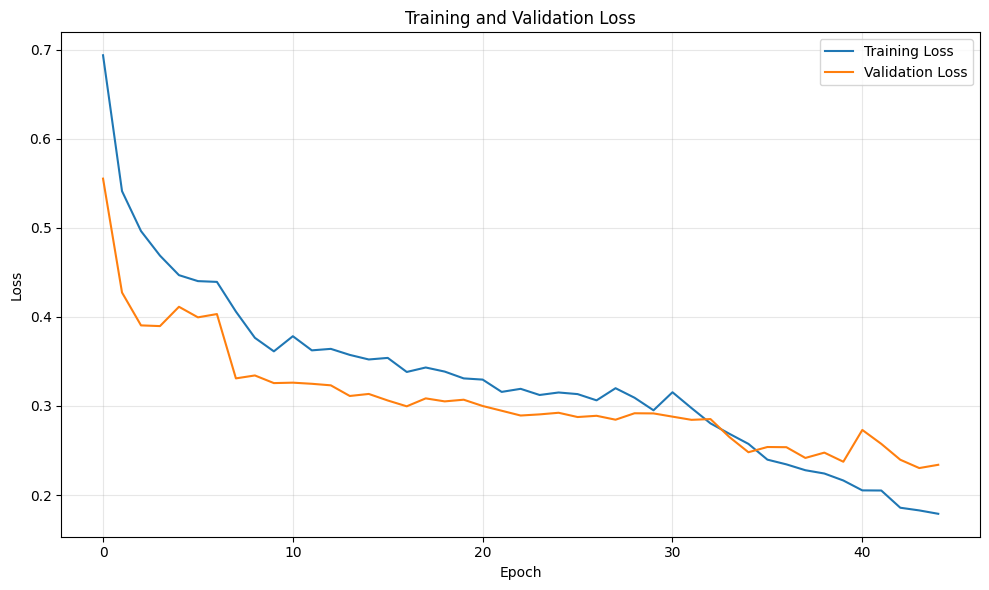

In [35]:
loss = history.history["loss"] + fine_tune_history.history["loss"]
val_loss = history.history["val_loss"] + fine_tune_history.history["val_loss"]

plt.figure(figsize=(10, 6))

plt.plot(loss, label="Training Loss")
plt.plot(val_loss, label="Validation Loss")

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/loss_curve.png", dpi=300)
plt.show()

## Test set evaluation


In [37]:
_, preprocess_function = get_backbone(BACKBONE_NAME)

custom_objects = {
    'preprocess_input': preprocess_function
}

best_model_path = os.path.join(
    OUTPUT_DIR,
    "best_brain_stroke_model.keras"
)

if os.path.exists(best_model_path):
    model = tf.keras.models.load_model(best_model_path, custom_objects=custom_objects)
    print("Best model loaded.")


test_loss, test_accuracy = model.evaluate(
    test_generator,
    verbose=1
)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)


test_generator.reset()

probabilities = model.predict(
    test_generator,
    verbose=1
)

predicted_labels = np.argmax(
    probabilities,
    axis=1
)

true_labels = test_generator.classes

Best model loaded.
84/84 ━━━━━━━━━━━━━━━━━━━━ 19s 120ms/step - accuracy: 0.9068 - loss: 0.2733
Test loss: 0.2732667922973633
Test accuracy: 0.906836986541748
84/84 ━━━━━━━━━━━━━━━━━━━━ 21s 150ms/step


## Classification report and per-class metrics


In [38]:
report = classification_report(
    true_labels,
    predicted_labels,
    target_names=CLASS_NAMES,
    digits=4
)

print(report)

with open(
    f"{OUTPUT_DIR}/classification_report.txt",
    "w"
) as f:
    f.write(report)


precision, recall, f1, support = precision_recall_fscore_support(
    true_labels,
    predicted_labels,
    average=None,
    labels=range(NUM_CLASSES)
)

metrics_df = pd.DataFrame({
    "Class": CLASS_NAMES,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1,
    "Support": support
})

display(metrics_df)


              precision    recall  f1-score   support

      Normal     0.9626    0.8628    0.9100       328
    Ischemia     0.8997    0.8201    0.8580       339
    Bleeding     0.8874    0.9729    0.9282       664

    accuracy                         0.9068      1331
   macro avg     0.9165    0.8853    0.8987      1331
weighted avg     0.9090    0.9068    0.9058      1331



,Class,Precision,Recall,F1 Score,Support
0,Normal,0.962585,0.862805,0.909968,328
1,Ischemia,0.899676,0.820059,0.858025,339
2,Bleeding,0.887363,0.972892,0.928161,664


# Confusion Matrix

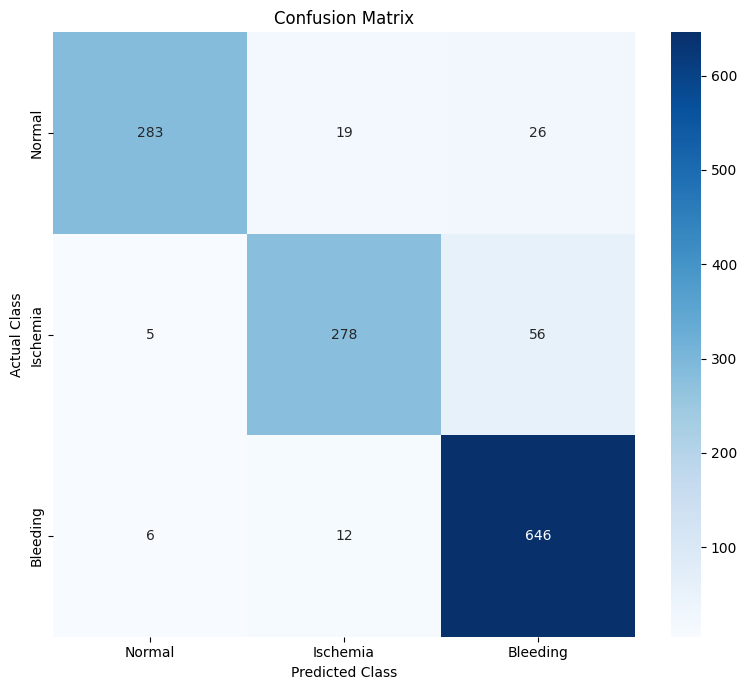

In [41]:
cm = confusion_matrix(
    true_labels,
    predicted_labels
)

plt.figure(figsize=(8, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/confusion_matrix.png", dpi=300)
plt.show()

# Normalized Confusion Matrix

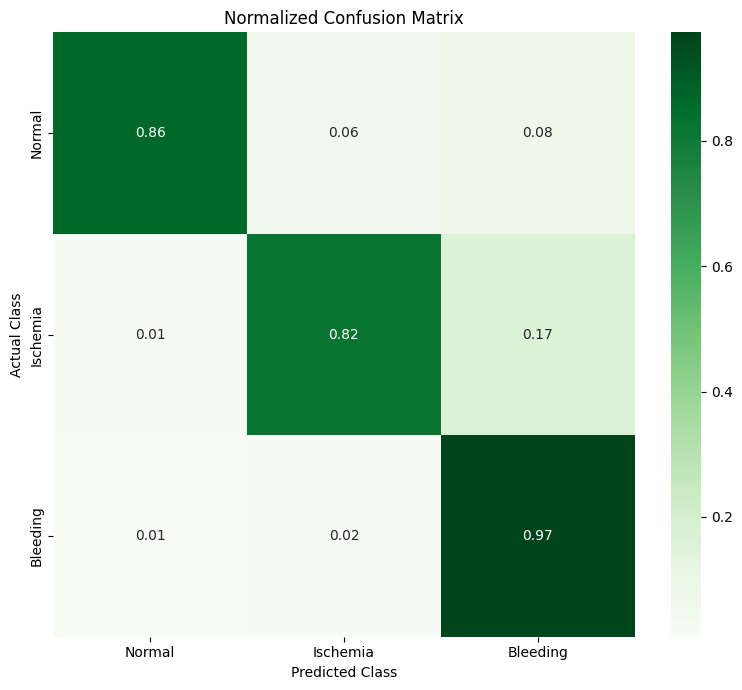

In [40]:
cm_normalized = cm.astype(float) / cm.sum(
    axis=1,
    keepdims=True
)

plt.figure(figsize=(8, 7))

sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="Greens",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.title("Normalized Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.tight_layout()
plt.savefig(
    f"{OUTPUT_DIR}/normalized_confusion_matrix.png",
    dpi=300
)
plt.show()

## Multi-class ROC curve and AUC


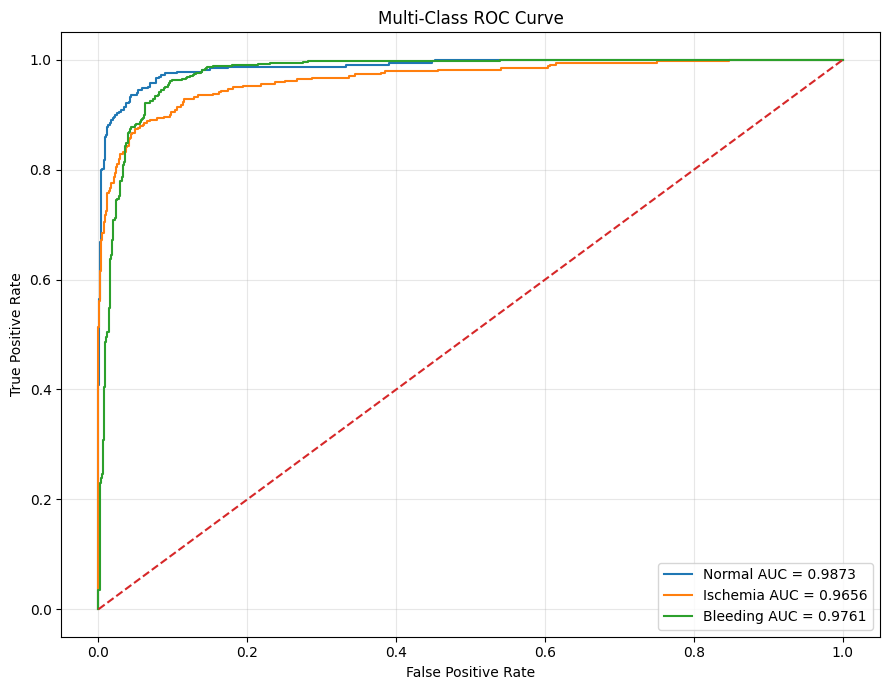

Macro ROC-AUC: 0.9763463678415604


In [42]:
true_labels_binary = label_binarize(
    true_labels,
    classes=np.arange(NUM_CLASSES)
)

plt.figure(figsize=(9, 7))

for i, class_name in enumerate(CLASS_NAMES):

    fpr, tpr, _ = roc_curve(
        true_labels_binary[:, i],
        probabilities[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{class_name} AUC = {roc_auc:.4f}"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.title("Multi-Class ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/roc_curve.png", dpi=300)
plt.show()


macro_auc = roc_auc_score(
    true_labels_binary,
    probabilities,
    multi_class="ovr",
    average="macro"
)

print("Macro ROC-AUC:", macro_auc)


## Error Analysis and Visualization


Number of incorrect predictions: 124


,filepath,actual,predicted,confidence
0,/content/Brain_Stroke_CT_Dataset/Bleeding/PNG/...,Normal,Bleeding,0.939017
1,/content/Brain_Stroke_CT_Dataset/Ischemia/PNG/...,Ischemia,Bleeding,0.736953
2,/content/Brain_Stroke_CT_Dataset/Ischemia/PNG/...,Ischemia,Bleeding,0.684214
3,/content/Brain_Stroke_CT_Dataset/Bleeding/PNG/...,Normal,Ischemia,0.515091
4,/content/Brain_Stroke_CT_Dataset/Bleeding/PNG/...,Normal,Bleeding,0.526578
5,/content/Brain_Stroke_CT_Dataset/Ischemia/PNG/...,Ischemia,Bleeding,0.529627
6,/content/Brain_Stroke_CT_Dataset/Bleeding/PNG/...,Normal,Ischemia,0.570196
7,/content/Brain_Stroke_CT_Dataset/Bleeding/PNG/...,Normal,Bleeding,0.664443
8,/content/Brain_Stroke_CT_Dataset/Normal/PNG/12...,Bleeding,Ischemia,0.495985
9,/content/Brain_Stroke_CT_Dataset/Bleeding/PNG/...,Normal,Bleeding,0.665292


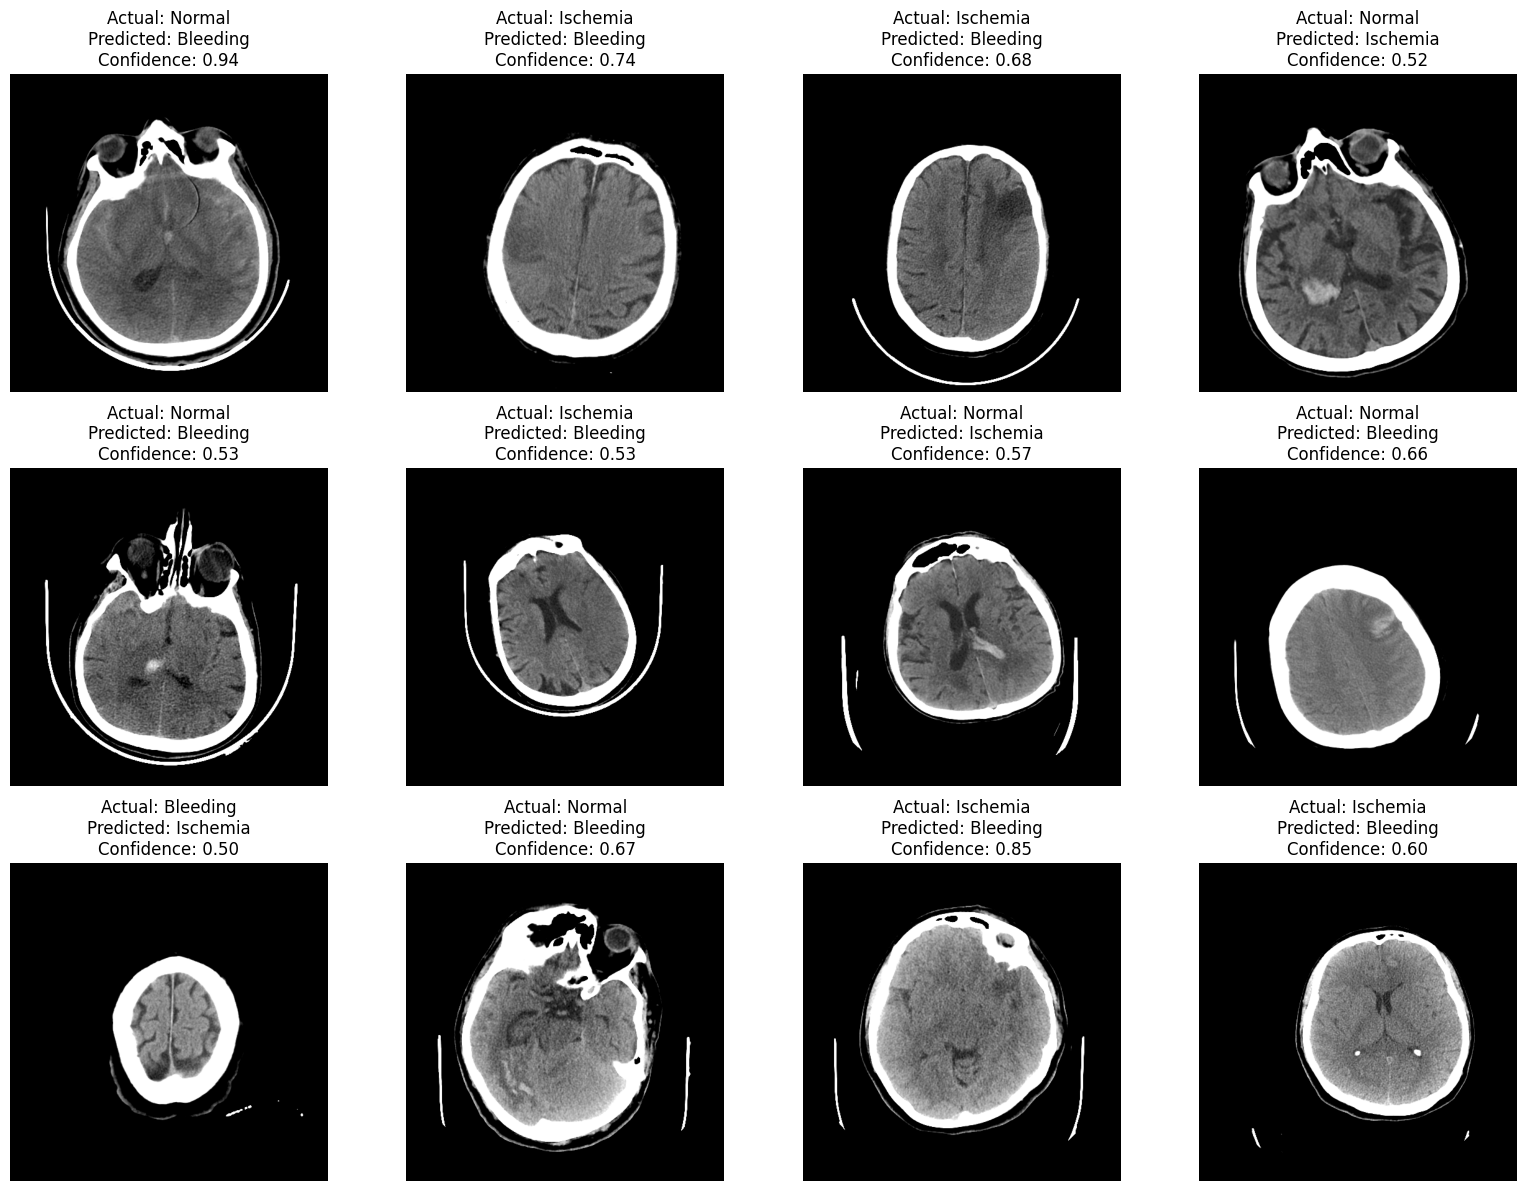

In [43]:
errors = []

for i in range(len(test_df)):

    actual = true_labels[i]
    predicted = predicted_labels[i]

    if actual != predicted:

        errors.append({
            "filepath": test_df.iloc[i]["filepath"],
            "actual": CLASS_NAMES[actual],
            "predicted": CLASS_NAMES[predicted],
            "confidence": probabilities[i][predicted]
        })

errors_df = pd.DataFrame(errors)

print("Number of incorrect predictions:", len(errors_df))

display(errors_df.head(20))


if len(errors_df) > 0:

    number_to_display = min(12, len(errors_df))
    samples = errors_df.head(number_to_display)

    columns = 4
    rows = int(np.ceil(number_to_display / columns))

    fig, axes = plt.subplots(
        rows,
        columns,
        figsize=(16, rows * 4)
    )

    axes = np.array(axes).reshape(rows, columns)

    for i, (_, row) in enumerate(samples.iterrows()):

        image = Image.open(
            row["filepath"]
        ).convert("RGB")

        r = i // columns
        c = i % columns

        axes[r, c].imshow(image)

        axes[r, c].set_title(
            f"Actual: {row['actual']}\n"
            f"Predicted: {row['predicted']}\n"
            f"Confidence: {row['confidence']:.2f}"
        )

        axes[r, c].axis("off")

    for i in range(
        number_to_display,
        rows * columns
    ):
        r = i // columns
        c = i % columns
        axes[r, c].axis("off")

    plt.tight_layout()
    plt.savefig(
        f"{OUTPUT_DIR}/prediction_errors.png",
        dpi=300
    )
    plt.show()
else:
    print("No misclassified test images.")


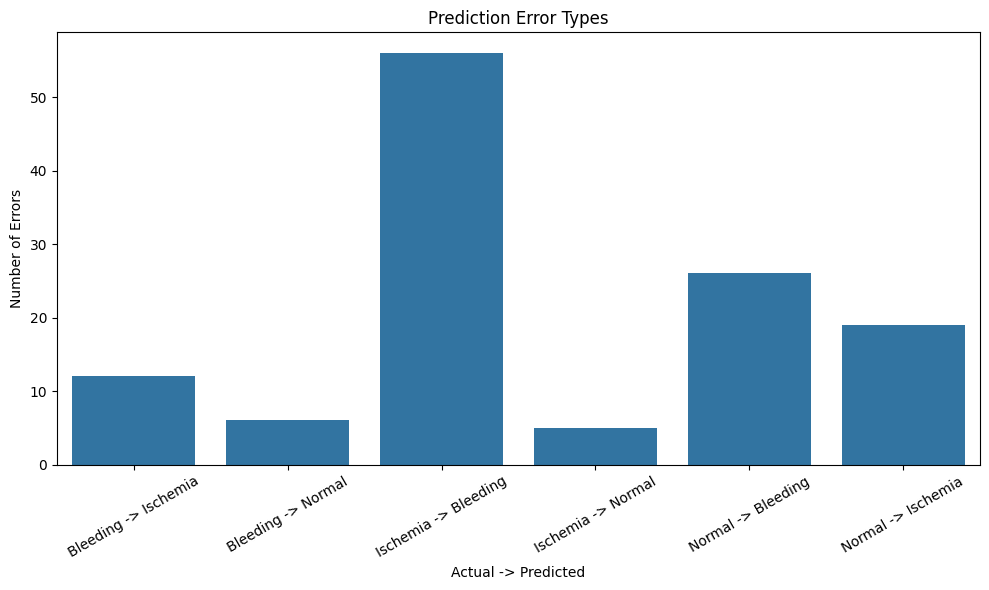

In [44]:
if len(errors_df) > 0:

    error_types = (
        errors_df
        .groupby(["actual", "predicted"])
        .size()
        .reset_index(name="count")
    )

    error_types["error_type"] = (
        error_types["actual"]
        + " -> "
        + error_types["predicted"]
    )

    plt.figure(figsize=(10, 6))

    sns.barplot(
        data=error_types,
        x="error_type",
        y="count"
    )

    plt.title("Prediction Error Types")
    plt.xlabel("Actual -> Predicted")
    plt.ylabel("Number of Errors")
    plt.xticks(rotation=30)

    plt.tight_layout()
    plt.savefig(
        f"{OUTPUT_DIR}/error_types.png",
        dpi=300
    )
    plt.show()


## Prediction confidence


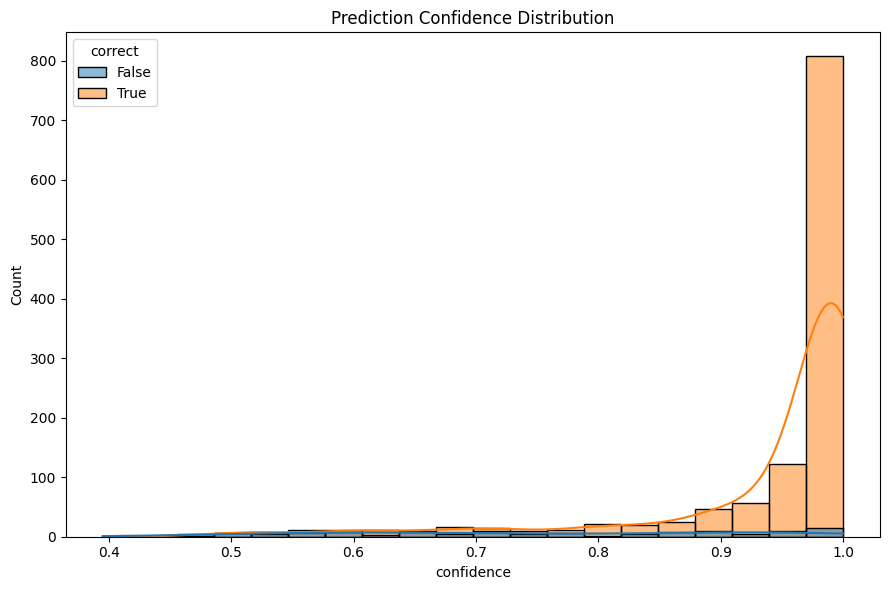

In [45]:
confidence_scores = np.max(
    probabilities,
    axis=1
)

confidence_df = pd.DataFrame({
    "confidence": confidence_scores,
    "correct": true_labels == predicted_labels
})

plt.figure(figsize=(9, 6))

sns.histplot(
    data=confidence_df,
    x="confidence",
    hue="correct",
    bins=20,
    kde=True
)

plt.title("Prediction Confidence Distribution")
plt.tight_layout()
plt.savefig(
    f"{OUTPUT_DIR}/confidence_distribution.png",
    dpi=300
)
plt.show()


## Save all results


In [46]:
prediction_df = test_df.copy()

prediction_df["true_class"] = [
    CLASS_NAMES[x] for x in true_labels
]

prediction_df["predicted_class"] = [
    CLASS_NAMES[x] for x in predicted_labels
]

prediction_df["confidence"] = confidence_scores

for i, class_name in enumerate(CLASS_NAMES):

    prediction_df[
        f"probability_{class_name}"
    ] = probabilities[:, i]

prediction_df.to_csv(
    f"{OUTPUT_DIR}/test_predictions.csv",
    index=False
)


features_df.to_csv(
    f"{OUTPUT_DIR}/engineered_features.csv",
    index=False
)

feature_scores.to_csv(
    f"{OUTPUT_DIR}/feature_selection_scores.csv",
    index=False
)


model.save(
    f"{OUTPUT_DIR}/final_brain_stroke_model.keras"
)

print("Results saved to:", OUTPUT_DIR)


Results saved to: /content/brain_stroke_outputs


## Single-image prediction


In [47]:
def predict_single_image(
    image_path,
    trained_model=model
):

    image = load_img(
        image_path,
        target_size=(IMG_SIZE, IMG_SIZE)
    )

    image_array = img_to_array(image)
    image_array = np.expand_dims(
        image_array,
        axis=0
    )

    probabilities = trained_model.predict(
        image_array,
        verbose=0
    )[0]

    predicted_index = np.argmax(
        probabilities
    )

    predicted_class = CLASS_NAMES[
        predicted_index
    ]

    confidence = probabilities[
        predicted_index
    ]

    print("Prediction:", predicted_class)
    print(
        f"Confidence: {confidence * 100:.2f}%"
    )

    print("\nClass probabilities:")

    for i, class_name in enumerate(CLASS_NAMES):
        print(
            f"{class_name}: "
            f"{probabilities[i] * 100:.2f}%"
        )

    plt.figure(figsize=(6, 6))
    plt.imshow(Image.open(image_path).convert("RGB"))
    plt.title(
        f"Prediction: {predicted_class}\n"
        f"Confidence: {confidence * 100:.2f}%"
    )
    plt.axis("off")
    plt.show()

    return predicted_class, confidence, probabilities


# Example:
#
# TEST_IMAGE = "/content/my_brain_ct.jpg"
# predict_single_image(TEST_IMAGE)


Prediction: Bleeding
Confidence: 97.42%

Class probabilities:
Normal: 2.46%
Ischemia: 0.12%
Bleeding: 97.42%


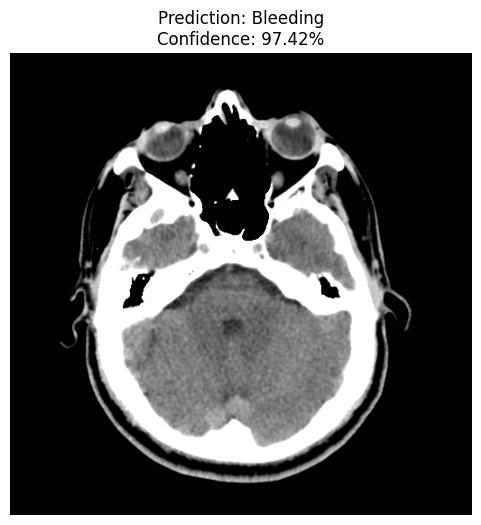

('Bleeding',
 np.float32(0.97421885),
 array([0.02457516, 0.00120594, 0.97421885], dtype=float32))

In [48]:
TEST_IMAGE = "/content/Brain_Stroke_CT_Dataset/Normal/PNG/10006.png"
predict_single_image(TEST_IMAGE)

Prediction: Bleeding
Confidence: 99.38%

Class probabilities:
Normal: 0.15%
Ischemia: 0.47%
Bleeding: 99.38%


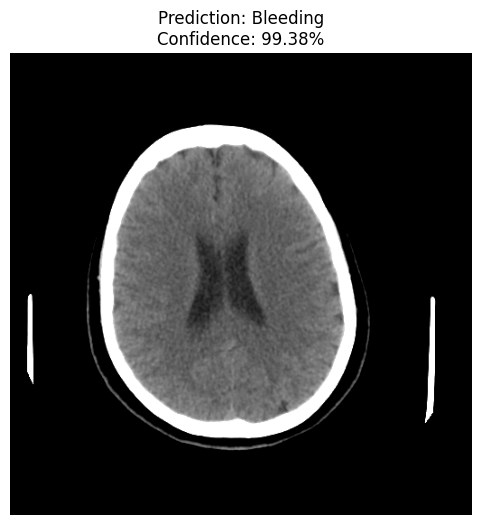

('Bleeding',
 np.float32(0.99384916),
 array([0.00148597, 0.00466485, 0.99384916], dtype=float32))

In [49]:
TEST_IMAGE = "/content/Brain_Stroke_CT_Dataset/Normal/PNG/10010.png"
predict_single_image(TEST_IMAGE)

Prediction: Bleeding
Confidence: 75.58%

Class probabilities:
Normal: 24.28%
Ischemia: 0.14%
Bleeding: 75.58%


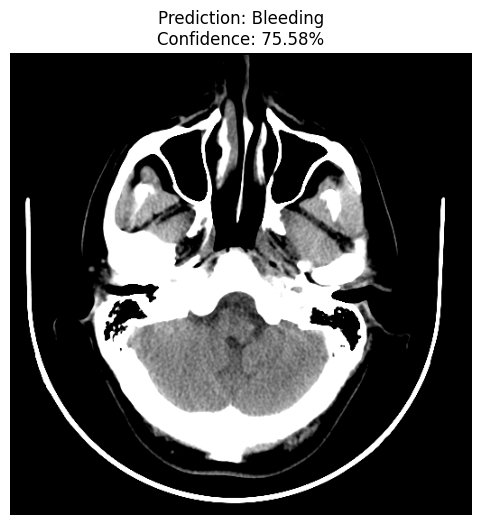

('Bleeding',
 np.float32(0.7558249),
 array([0.24276128, 0.00141383, 0.7558249 ], dtype=float32))

In [50]:
TEST_IMAGE = "/content/Brain_Stroke_CT_Dataset/External_Test/PNG/10200.png"
predict_single_image(TEST_IMAGE)

Prediction: Bleeding
Confidence: 54.25%

Class probabilities:
Normal: 25.38%
Ischemia: 20.38%
Bleeding: 54.25%


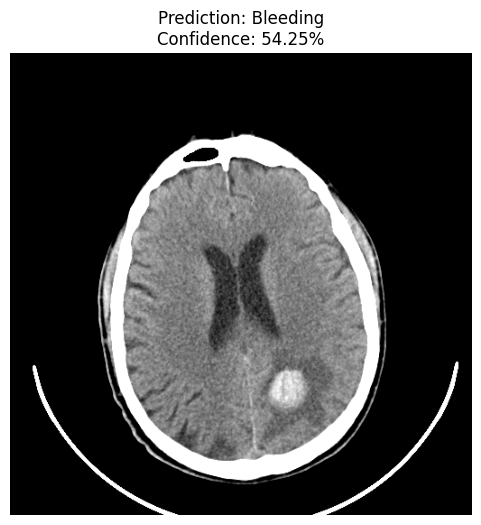

('Bleeding',
 np.float32(0.542474),
 array([0.2537538 , 0.20377228, 0.542474  ], dtype=float32))

In [51]:
TEST_IMAGE = "/content/Brain_Stroke_CT_Dataset/Bleeding/PNG/10036.png"
predict_single_image(TEST_IMAGE)

Prediction: Normal
Confidence: 52.47%

Class probabilities:
Normal: 52.47%
Ischemia: 36.30%
Bleeding: 11.23%


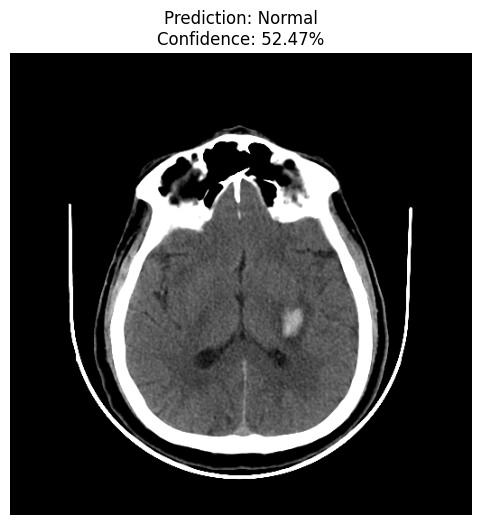

('Normal',
 np.float32(0.52470756),
 array([0.52470756, 0.36295384, 0.11233855], dtype=float32))

In [52]:
TEST_IMAGE = "/content/Brain_Stroke_CT_Dataset/Bleeding/PNG/10045.png"
predict_single_image(TEST_IMAGE)

## Save Model

In [56]:
import os

os.makedirs("models", exist_ok=True)

model.save("models/brain_stroke_model.keras")

print("Model saved successfully!")

Model saved successfully!


In [58]:
_, preprocess_function = get_backbone(BACKBONE_NAME)

custom_objects = {
    'preprocess_input': preprocess_function
}

model = tf.keras.models.load_model("models/brain_stroke_model.keras", custom_objects=custom_objects)

In [60]:
from google.colab import files

files.download('models/brain_stroke_model.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>